This notebook installs necessary libraries for data analysis and machine learning, sets up Kaggle for dataset access, and lists available Kaggle datasets.


# Brain Tumor Classification using Deep Learning
SE4050 - Deep Learning Project
Team Members: Dhanithya Beligolla

Dataset: Brain Tumor MRI Images
Models: Custom CNN, VGG16, ResNet50, EfficientNetB0



## 1) COLAB & ENV SETUP

In [1]:

!nvidia-smi -L || true

# Quiet installs (tf-addons used for metrics later, imagehash used for duplicate checks)
!pip -q install tensorflow-addons imagehash imbalanced-learn scikit-plot > /dev/null

import os, random, numpy as np, tensorflow as tf, warnings
warnings.filterwarnings('ignore')

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))


GPU 0: NVIDIA L4 (UUID: GPU-d2c9ed43-aa0d-7aa0-0c17-f2bf469ebede)
ERROR: Could not find a version that satisfies the requirement tensorflow-addons (from versions: none)
ERROR: No matching distribution found for tensorflow-addons
TensorFlow: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]



## 2) Kaggle Setup & Dataset Download
We will download **Brain Tumor MRI Dataset (4 classes)** from Kaggle.  
**Instructions:**  
1. In Colab, go to **left sidebar → Files** and verify this notebook's working directory is `/content`.  
2. Run the cell below, then **upload your `kaggle.json`** (from Kaggle → *Account* → *Settings* → *Create New API Token*).  


In [2]:

from pathlib import Path
from google.colab import files

kaggle_dir = Path("/root/.kaggle")
kaggle_dir.mkdir(parents=True, exist_ok=True)

print("➡️ Please upload your kaggle.json in the next prompt.")
uploaded = files.upload()  # user uploads kaggle.json

if "kaggle.json" in uploaded:
    import shutil, stat
    shutil.move("kaggle.json", kaggle_dir/"kaggle.json")
    os.chmod(kaggle_dir/"kaggle.json", stat.S_IRUSR | stat.S_IWUSR)
    print("✅ kaggle.json installed.")
else:
    raise RuntimeError("kaggle.json not uploaded. Please rerun and upload.")


➡️ Please upload your kaggle.json in the next prompt.


Saving kaggle.json to kaggle.json
✅ kaggle.json installed.


In [3]:

!pip -q install kaggle > /dev/null

proj_root = Path("/content/brain_tumor_project")
data_root = proj_root/"data"
proj_root.mkdir(exist_ok=True, parents=True)

# Download the dataset
%cd /content
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset -p /content -o
!unzip -q -o /content/brain-tumor-mri-dataset.zip -d {str(data_root)}
!rm -f /content/brain-tumor-mri-dataset.zip

print("📂 Extracted to:", data_root)
!find {str(data_root)} -maxdepth 2 -type d -print


/content
Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): CC0-1.0
  0% 0.00/149M [00:00<?, ?B/s]
100% 149M/149M [00:00<00:00, 1.68GB/s]
📂 Extracted to: /content/brain_tumor_project/data
/content/brain_tumor_project/data
/content/brain_tumor_project/data/Testing
/content/brain_tumor_project/data/Testing/pituitary
/content/brain_tumor_project/data/Testing/notumor
/content/brain_tumor_project/data/Testing/glioma
/content/brain_tumor_project/data/Testing/meningioma
/content/brain_tumor_project/data/Training
/content/brain_tumor_project/data/Training/pituitary
/content/brain_tumor_project/data/Training/notumor
/content/brain_tumor_project/data/Training/glioma
/content/brain_tumor_project/data/Training/meningioma


## 3) Dataset Structure Overview

In [4]:

import os, pandas as pd

TRAIN_DIR = os.path.join(str(data_root), "Training")
TEST_DIR  = os.path.join(str(data_root), "Testing")
CLASSES   = ['glioma','meningioma','notumor','pituitary']

def count_images(root):
    rows = []
    for c in CLASSES:
        p = os.path.join(root, c)
        if os.path.exists(p):
            n = sum([1 for f in os.listdir(p) if f.lower().endswith(('.png','.jpg','.jpeg'))])
            rows.append((c, n))
        else:
            rows.append((c, 0))
    return pd.DataFrame(rows, columns=["Class","Count"])

print("Train distribution:")
display(count_images(TRAIN_DIR))
print("Test distribution:")
display(count_images(TEST_DIR))


Train distribution:


,Class,Count
0,glioma,1321
1,meningioma,1339
2,notumor,1595
3,pituitary,1457


Test distribution:


,Class,Count
0,glioma,300
1,meningioma,306
2,notumor,405
3,pituitary,300



## 4) Robust Image Loader (Integrity Checks)
- Reads images, converts to RGB, resizes to `224×224`.  
- Skips unreadable/corrupted files.  
- Records problematic files for review.  


In [5]:

import cv2, numpy as np
from glob import glob

IMG_SIZE = (224, 224)

def load_images_from_dir(dir_path, classes):
    X, y, paths, bad_files = [], [], [], []
    for ci, cname in enumerate(classes):
        cdir = os.path.join(dir_path, cname)
        if not os.path.exists(cdir):
            continue
        for fp in glob(os.path.join(cdir, "*")):
            if not fp.lower().endswith(('.png','.jpg','.jpeg')):
                continue
            try:
                img_bgr = cv2.imread(fp)
                if img_bgr is None:
                    bad_files.append(fp); continue
                img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
                img_rgb = cv2.resize(img_rgb, IMG_SIZE, interpolation=cv2.INTER_AREA)
                X.append(img_rgb); y.append(ci); paths.append(fp)
            except Exception as e:
                bad_files.append(fp)
    return np.array(X), np.array(y), paths, bad_files

X_train_all, y_train_all, train_paths, bad_train = load_images_from_dir(TRAIN_DIR, CLASSES)
X_test_raw,  y_test_raw,  test_paths,  bad_test  = load_images_from_dir(TEST_DIR,  CLASSES)

print(f"Loaded TRAIN images: {X_train_all.shape} | bad files: {len(bad_train)}")
print(f"Loaded TEST images:  {X_test_raw.shape}  | bad files: {len(bad_test)}")

if bad_train or bad_test:
    print("⚠️ Bad files detected (first 10 shown):")
    print((bad_train + bad_test)[:10])


Loaded TRAIN images: (5712, 224, 224, 3) | bad files: 0
Loaded TEST images:  (1311, 224, 224, 3)  | bad files: 0



## 5) Duplicate Detection & Removal
We detect **exact duplicates** using perceptual hashing (average hash). Duplicates in **Training** are removed to avoid leakage and bias.


In [6]:
!pip install imagehash Pillow
import imagehash
from PIL import Image

def find_duplicates(paths):
    seen = {}
    dups = []
    for fp in paths:
        try:
            with Image.open(fp) as im:
                im = im.convert("RGB").resize((128,128), Image.BILINEAR)
                h = str(imagehash.average_hash(im))
            if h in seen:
                dups.append((fp, seen[h]))
            else:
                seen[h] = fp
        except Exception:
            # Skip unreadable in hashing step
            pass
    return dups

dups_train = find_duplicates(train_paths)
print(f"Found {len(dups_train)} potential duplicate pairs in TRAIN (show first 5):")
print(dups_train[:5])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 22.3 MB/s eta 0:00:00
Found 2642 potential duplicate pairs in TRAIN (show first 5):
[('/content/brain_tumor_project/data/Training/glioma/Tr-gl_0199.jpg', '/content/brain_tumor_project/data/Training/glioma/Tr-gl_0276.jpg'), ('/content/brain_tumor_project/data/Training/glioma/Tr-gl_0245.jpg', '/content/brain_tumor_project/data/Training/glioma/Tr-gl_1150.jpg'), ('/content/brain_tumor_project/data/Training/glioma/Tr-gl_0380.jpg', '/content/brain_tumor_project/data/Training/glioma/Tr-gl_0564.jpg'), ('/content/brain_tumor_project/data/Training/glioma/Tr-gl_0215.jpg', '/content/brain_tumor_project/data/Training/glioma/Tr-gl_0214.jpg'), ('/content/brain_tumor_project/data/Training/glioma/Tr-gl_0270.jpg', '/content/brain_tumor_project/data/Training/glioma/Tr-gl_1150.jpg')]


In [7]:

# Build a keep/remove mask for training
to_remove = set([a for a,b in dups_train])  # remove the 'later' occurrence
keep_mask = np.array([p not in to_remove for p in train_paths])

X_train_all = X_train_all[keep_mask]
y_train_all = y_train_all[keep_mask]
train_paths = [p for i,p in enumerate(train_paths) if keep_mask[i]]

print("After duplicate removal -> TRAIN:", X_train_all.shape)


After duplicate removal -> TRAIN: (3070, 224, 224, 3)



## 6) Stratified Split (Training→Train/Val) & Preserve Official Test
We use **Training** for `train/val` (stratified, 85/15) and the dataset's official **Testing** as our `test` set.


In [8]:

from sklearn.model_selection import train_test_split
import pandas as pd

X_train, X_val, y_train, y_val, train_paths_final, val_paths = train_test_split(
    X_train_all, y_train_all, train_paths, test_size=0.15, random_state=SEED, stratify=y_train_all
)

X_test, y_test = X_test_raw, y_test_raw

def dist(y):
    import numpy as np, pandas as pd
    u, c = np.unique(y, return_counts=True)
    return pd.DataFrame({'Class':[CLASSES[i] for i in u], 'Count':c})

print("Train dist:"); display(dist(y_train))
print("Val dist:");   display(dist(y_val))
print("Test dist:");  display(dist(y_test))

print("Shapes -> Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)


Train dist:


,Class,Count
0,glioma,697
1,meningioma,715
2,notumor,415
3,pituitary,782


Val dist:


,Class,Count
0,glioma,123
1,meningioma,127
2,notumor,73
3,pituitary,138


Test dist:


,Class,Count
0,glioma,300
1,meningioma,306
2,notumor,405
3,pituitary,300


Shapes -> Train: (2609, 224, 224, 3) Val: (461, 224, 224, 3) Test: (1311, 224, 224, 3)



## 7) Preprocessing Pipelines & Class Weights
- **Normalization**: scale to `[0,1]` now (transfer-learning specific preprocessing can be added later per backbone).  
- **Class weights** computed from the training distribution (used during training phase, not here).  


In [9]:

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Normalize to [0,1] for now (generic)
X_train_f = (X_train.astype('float32')/255.0)
X_val_f   = (X_val.astype('float32')/255.0)
X_test_f  = (X_test.astype('float32')/255.0)

# Compute class weights on train
classes_idx = np.arange(len(CLASSES))
cw = compute_class_weight(class_weight='balanced', classes=classes_idx, y=y_train)
class_weights = {i: float(w) for i,w in enumerate(cw)}
class_weights


{0: 0.9357962697274032,
 1: 0.9122377622377622,
 2: 1.5716867469879519,
 3: 0.834079283887468}


## 8) Visual Sanity Checks
We confirm shapes, ranges, and sample visuals **after preprocessing**.


Ranges -> Train min/max: 0.0 1.0
Ranges -> Val   min/max: 0.0 1.0
Ranges -> Test  min/max: 0.0 1.0


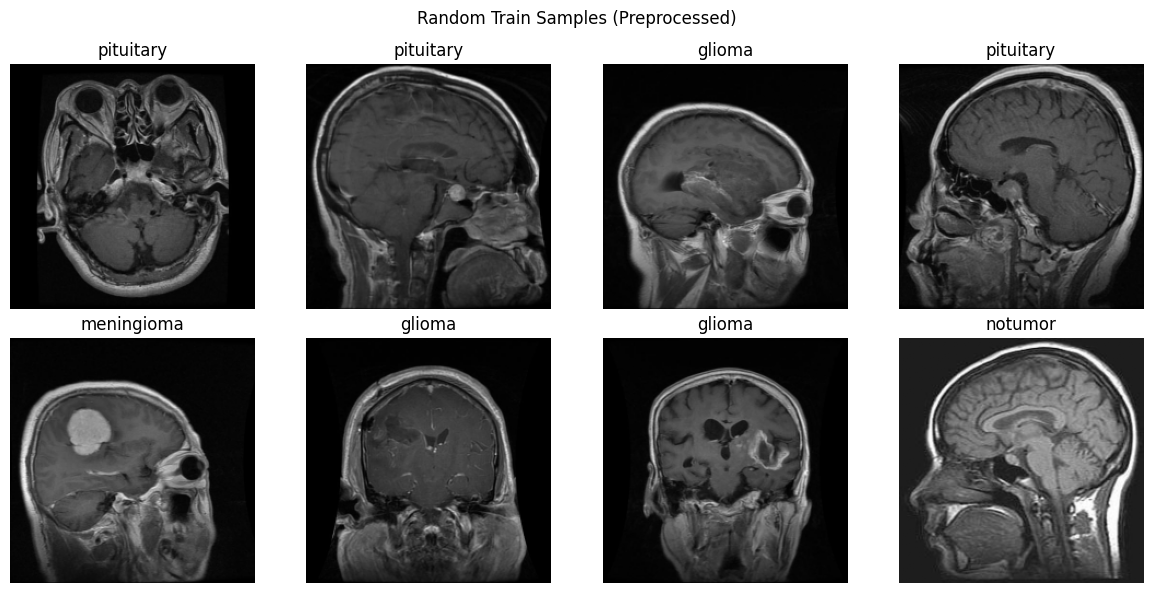

In [10]:

import matplotlib.pyplot as plt
import numpy as np

print("Ranges -> Train min/max:", X_train_f.min(), X_train_f.max())
print("Ranges -> Val   min/max:", X_val_f.min(), X_val_f.max())
print("Ranges -> Test  min/max:", X_test_f.min(), X_test_f.max())

# Show a grid of random training samples
idxs = np.random.choice(len(X_train_f), size=8, replace=False)
plt.figure(figsize=(12,6))
for i,ix in enumerate(idxs):
    plt.subplot(2,4,i+1)
    plt.imshow(X_train_f[ix])
    plt.title(CLASSES[y_train[ix]])
    plt.axis('off')
plt.suptitle("Random Train Samples (Preprocessed)")
plt.tight_layout(); plt.show()



## 9) Save Cleaned Splits (Optional)
Saves NumPy arrays so teammates can load the same cleaned data without re-running integrity checks.


In [11]:

import numpy as np, os
clean_dir = os.path.join(str(proj_root), "clean_np")
os.makedirs(clean_dir, exist_ok=True)

np.save(os.path.join(clean_dir, "X_train.npy"), X_train_f)
np.save(os.path.join(clean_dir, "y_train.npy"), y_train)
np.save(os.path.join(clean_dir, "X_val.npy"),   X_val_f)
np.save(os.path.join(clean_dir, "y_val.npy"),   y_val)
np.save(os.path.join(clean_dir, "X_test.npy"),  X_test_f)
np.save(os.path.join(clean_dir, "y_test.npy"),  y_test)

with open(os.path.join(clean_dir, "class_weights.json"), "w") as f:
    import json; json.dump(class_weights, f, indent=2)

print("📦 Saved cleaned arrays to:", clean_dir)
!ls -lh {clean_dir}


📦 Saved cleaned arrays to: /content/brain_tumor_project/clean_np
total 2.5G
-rw-r--r-- 1 root root  109 Oct 12 17:40 class_weights.json
-rw-r--r-- 1 root root 753M Oct 12 17:40 X_test.npy
-rw-r--r-- 1 root root 1.5G Oct 12 17:40 X_train.npy
-rw-r--r-- 1 root root 265M Oct 12 17:40 X_val.npy
-rw-r--r-- 1 root root  11K Oct 12 17:40 y_test.npy
-rw-r--r-- 1 root root  21K Oct 12 17:40 y_train.npy
-rw-r--r-- 1 root root 3.8K Oct 12 17:40 y_val.npy



# 🧠 Brain Tumor MRI — **Custom CNN (Baseline) Training & Evaluation**
**Scope:** Load **cleaned arrays** from preprocessing, build **Custom CNN from scratch**, train with class weights, and evaluate on the official **Testing** set with Accuracy / Precision / Recall / F1 and confusion matrix.


In [25]:
!nvidia-smi -L || true
!pip -q install tensorflow-addons scikit-plot > /dev/null

import os, random, json, numpy as np, tensorflow as tf, matplotlib.pyplot as plt
from pathlib import Path
import warnings; warnings.filterwarnings('ignore')
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

from tensorflow.keras import mixed_precision
# mixed_precision.set_global_policy("mixed_float16") # Commented out to disable mixed precision

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

GPU 0: NVIDIA L4 (UUID: GPU-d2c9ed43-aa0d-7aa0-0c17-f2bf469ebede)
TensorFlow: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2) Load Cleaned Data (from preprocessing notebook)

In [26]:

proj_root = Path("/content/brain_tumor_project")
clean_dir = proj_root/"clean_np"
assert (clean_dir/"X_train.npy").exists(), "Clean arrays not found. Run the preprocessing notebook first."

X_train = np.load(clean_dir/"X_train.npy")
y_train = np.load(clean_dir/"y_train.npy")
X_val   = np.load(clean_dir/"X_val.npy")
y_val   = np.load(clean_dir/"y_val.npy")
X_test  = np.load(clean_dir/"X_test.npy")
y_test  = np.load(clean_dir/"y_test.npy")

with open(clean_dir/"class_weights.json") as f:
    class_weights = {int(k): float(v) for k,v in json.load(f).items()}

CLASSES = ['glioma','meningioma','notumor','pituitary']
IMG_SIZE = (224,224)
NUM_CLASSES = len(CLASSES)

X_train.shape, X_val.shape, X_test.shape, class_weights


((2609, 224, 224, 3),
 (461, 224, 224, 3),
 (1311, 224, 224, 3),
 {0: 0.9357962697274032,
  1: 0.9122377622377622,
  2: 1.5716867469879519,
  3: 0.834079283887468})

## 3) tf.data Pipelines with Augmentation

In [41]:
AUTO = tf.data.AUTOTUNE
BATCH = 32

def aug_fn(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, 0.10)
    img = tf.image.random_contrast(img, 0.9, 1.1)
    return img, tf.cast(label, tf.int32)  # <— ensure scalar int label

def make_ds(X, y, training=True):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if training:
        ds = ds.shuffle(8192, seed=42, reshuffle_each_iteration=True)
        ds = ds.map(aug_fn, num_parallel_calls=AUTO)
    else:
        # still cast on val/test to be safe
        ds = ds.map(lambda a,b: (a, tf.cast(b, tf.int32)), num_parallel_calls=AUTO)
    ds = ds.batch(BATCH).prefetch(AUTO)
    return ds

ds_train = make_ds(X_train, y_train, training=True)
ds_val   = make_ds(X_val,   y_val,   training=False)  # not shuffled
ds_test  = make_ds(X_test,  y_test,  training=False)


## 4) Custom CNN Architecture (Baseline)

In [42]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, BatchNormalization,
                                     Dropout, Flatten, Dense, Input)

def create_custom_cnn(input_shape=(224,224,3), num_classes=4):
    model = Sequential(name="Custom_CNN_Baseline")
    # Block 1
    model.add(Input(shape=input_shape))
    model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2,2)))
    model.add(Dropout(0.25))
    # Block 2
    model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2,2)))
    model.add(Dropout(0.25))
    # Block 3
    model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2,2)))
    model.add(Dropout(0.30))
    # Dense
    model.add(Flatten())
    model.add(Dense(512, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.50))
    model.add(Dense(256, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.50))
    model.add(Dense(num_classes, activation='softmax', dtype='float32'))
    return model

model = create_custom_cnn(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), num_classes=NUM_CLASSES)
model.summary()


Model: "Custom_CNN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │    51,380,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 51,804,964 (197.62 MB)

 Trainable params: 51,802,532 (197.61 MB)

 Non-trainable params: 2,432 (9.50 KB)

## 5) Compile & Callbacks

In [29]:
!pip install tensorflow-addons scikit-plot > /dev/null

In [47]:
# import tensorflow_addons as tfa # Removed due to compatibility issues
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

lr = 1e-3
import tensorflow as tf

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']  # <— only accuracy here
)



save_dir = proj_root/"models"
save_dir.mkdir(parents=True, exist_ok=True)
# ckpt_f1 = ModelCheckpoint(str(save_dir/"customcnn_best_f1.keras"), monitor='val_f1', mode='max', save_best_only=True, verbose=1) # Removed due to removal of f1 metric
ckpt_loss = ModelCheckpoint(str(save_dir/"customcnn_best_loss.keras"), monitor='val_loss', mode='min', save_best_only=True, verbose=1)
es = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1)
rlr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)
# callbacks = [ckpt_f1, ckpt_loss, es, rlr] # Updated callbacks list
callbacks = [ckpt_loss, es, rlr]
callbacks

## 6) Train Custom CNN

In [48]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np
import tensorflow as tf

class ValPRF1Callback(tf.keras.callbacks.Callback):
    def __init__(self, val_dataset, name_prefix='val'):
        super().__init__()
        self.val_dataset = val_dataset
        self.name_prefix = name_prefix

    def on_epoch_end(self, epoch, logs=None):
        y_true_all, y_pred_all = [], []
        for x, y in self.val_dataset:
            preds = self.model.predict(x, verbose=0)
            y_pred_all.append(np.argmax(preds, axis=1))
            y_true_all.append(y.numpy())
        y_true = np.concatenate(y_true_all, axis=0)
        y_pred = np.concatenate(y_pred_all, axis=0)

        p = precision_score(y_true, y_pred, average='macro', zero_division=0)
        r = recall_score(y_true, y_pred, average='macro', zero_division=0)
        f = f1_score(y_true, y_pred, average='macro', zero_division=0)

        logs = logs or {}
        logs[f'{self.name_prefix}_precision'] = p
        logs[f'{self.name_prefix}_recall']    = r
        logs[f'{self.name_prefix}_f1']        = f
        print(f"\nEpoch {epoch+1} — {self.name_prefix}_precision: {p:.4f}  "
              f"{self.name_prefix}_recall: {r:.4f}  {self.name_prefix}_f1: {f:.4f}")


In [49]:
save_dir = proj_root/"models"
save_dir.mkdir(parents=True, exist_ok=True)

val_prf1 = ValPRF1Callback(ds_val, name_prefix='val')

ckpt_f1 = tf.keras.callbacks.ModelCheckpoint(
    filepath=str(save_dir/"customcnn_best_f1.keras"),
    monitor='val_f1', mode='max', save_best_only=True, verbose=1
)
ckpt_loss = tf.keras.callbacks.ModelCheckpoint(
    filepath=str(save_dir/"customcnn_best_loss.keras"),
    monitor='val_loss', mode='min', save_best_only=True, verbose=1
)
es  = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1)
rlr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)

callbacks = [val_prf1, ckpt_f1, ckpt_loss, es, rlr]


In [50]:
EPOCHS = 40
history = model.fit(
    ds_train,
    validation_data=ds_val,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/40
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 662ms/step - accuracy: 0.4854 - loss: 1.6512
Epoch 1 — val_precision: 0.0748  val_recall: 0.2500  val_f1: 0.1152

Epoch 1: val_f1 improved from -inf to 0.11519, saving model to /content/brain_tumor_project/models/customcnn_best_f1.keras

Epoch 1: val_loss improved from inf to 7.14476, saving model to /content/brain_tumor_project/models/customcnn_best_loss.keras
82/82 ━━━━━━━━━━━━━━━━━━━━ 142s 955ms/step - accuracy: 0.4859 - loss: 1.6484 - val_accuracy: 0.2993 - val_loss: 7.1448 - val_precision: 0.0748 - val_recall: 0.2500 - val_f1: 0.1152 - learning_rate: 0.0010
Epoch 2/40
81/82 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.5787 - loss: 1.1244
Epoch 2 — val_precision: 0.2657  val_recall: 0.2877  val_f1: 0.1717

Epoch 2: val_f1 improved from 0.11519 to 0.17168, saving model to /content/brain_tumor_project/models/customcnn_best_f1.keras

Epoch 2: val_loss improved from 7.14476 to 4.89295, saving model to /content/brain_tumor_project/models/custo

## 7) Training Curves

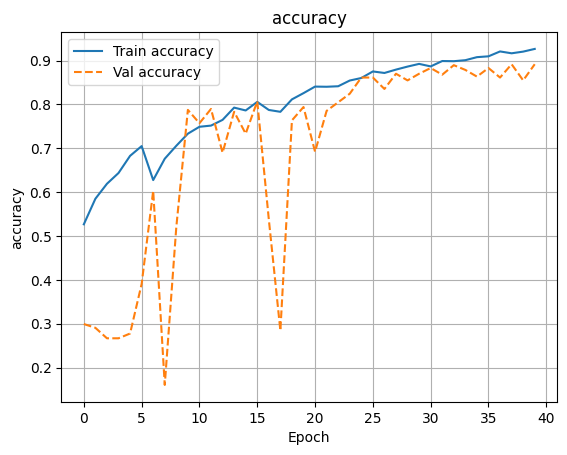

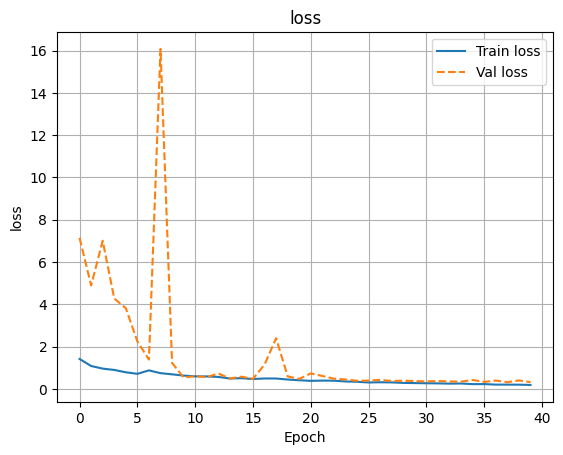

In [51]:

import matplotlib.pyplot as plt

def plot_history(H):
    keys = H.history.keys()
    for metric in ['accuracy','precision','recall','f1','loss']:
        if metric in keys and f'val_{metric}' in keys:
            plt.figure()
            plt.plot(H.history[metric], label=f'Train {metric}')
            plt.plot(H.history[f'val_{metric}'], label=f'Val {metric}', linestyle='--')
            plt.title(metric)
            plt.xlabel('Epoch'); plt.ylabel(metric); plt.legend(); plt.grid(True); plt.show()

plot_history(history)


## 8) Evaluation on Official Test Set

1.   List item
2.   List item



Test Accuracy : 0.8924
Test Precision: 0.8957
Test Recall   : 0.8881
Test F1-score : 0.8890

Classification Report:
              precision    recall  f1-score   support

      glioma     0.9213    0.7800    0.8448       300
  meningioma     0.7479    0.8824    0.8096       306
     notumor     0.9574    0.9432    0.9502       405
   pituitary     0.9562    0.9467    0.9514       300

    accuracy                         0.8924      1311
   macro avg     0.8957    0.8881    0.8890      1311
weighted avg     0.9000    0.8924    0.8935      1311



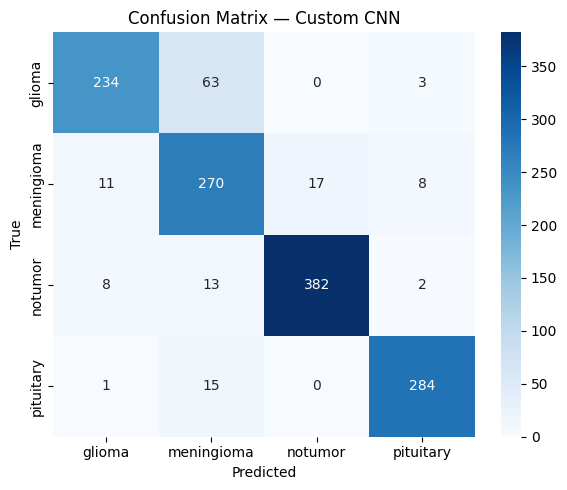

In [52]:

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import numpy as np, seaborn as sns

# Predict
y_prob = model.predict(ds_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
rec  = recall_score(y_test, y_pred, average='macro', zero_division=0)
f1   = f1_score(y_test, y_pred, average='macro', zero_division=0)
print(f"Test Accuracy : {acc:.4f}")
print(f"Test Precision: {prec:.4f}")
print(f"Test Recall   : {rec:.4f}")
print(f"Test F1-score : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=CLASSES, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
plt.title("Confusion Matrix — Custom CNN"); plt.ylabel("True"); plt.xlabel("Predicted"); plt.tight_layout(); plt.show()


## 9) Save Model & Artifacts

In [ ]:

model.save(str(save_dir/"customcnn_final.keras"))
metrics = {"accuracy": float(acc), "precision_macro": float(prec), "recall_macro": float(rec), "f1_macro": float(f1)}
with open(save_dir/"customcnn_test_metrics.json","w") as f:
    json.dump(metrics, f, indent=2)

with open(save_dir/"customcnn_history.json", "w") as f:
    json.dump(history.history, f, indent=2)

print("Saved:")
!ls -lh {str(save_dir)}
